In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep='\t',
    names=['label','message']
)

In [4]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df_copy = df.copy()

In [6]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [7]:
df_copy.shape

(5572, 2)

In [8]:
df_copy.isnull().sum()

label      0
message    0
dtype: int64

In [9]:
df_copy['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

Text(0, 0.5, 'Count')

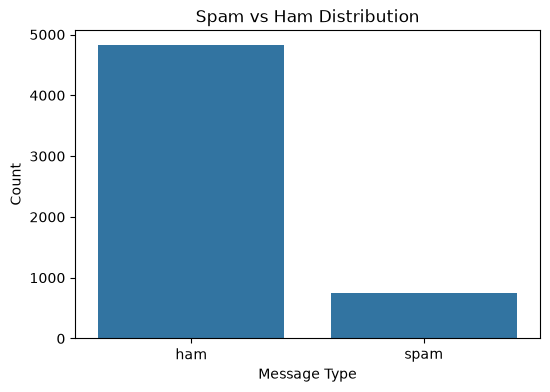

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_copy,x='label')

plt.title('Spam vs Ham Distribution')
plt.xlabel("Message Type")
plt.ylabel("Count")

In [11]:
df_copy['label_num'] = df_copy['label'].map({
    "ham":0,
    "spam":1
})

In [12]:
df_copy.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


# analyze message length

In [16]:
df_copy['message_length'] = df_copy['message'].apply(len)

In [17]:
df_copy.head()

,label,message,label_num,message_lengh,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,111
1,ham,Ok lar... Joking wif u oni...,0,29,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,155
3,ham,U dun say so early hor... U c already then say...,0,49,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,61


# compare the length of Spam vs Ham

In [18]:
df_copy.groupby('label')['message_length'].mean()

label
ham      71.482487
spam    138.670683
Name: message_length, dtype: float64

# visualize the   message length

Text(0.5, 1.0, 'Message length distribution')

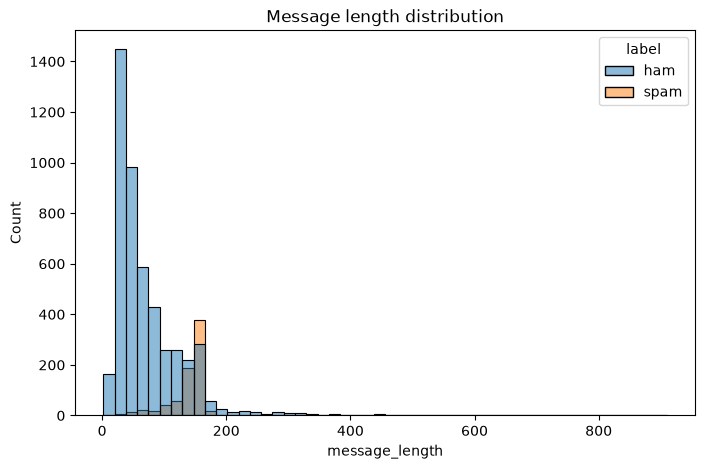

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(
    data = df_copy,
    x= 'message_length',
    hue='label',
    bins=50
)
plt.title("Message length distribution")

In [20]:
df_copy.duplicated().sum()

np.int64(403)

In [21]:
df_copy[df_copy.duplicated()].head()

,label,message,label_num,message_lengh,message_length
103,ham,As per your request 'Melle Melle (Oru Minnamin...,0,160,160
154,ham,As per your request 'Melle Melle (Oru Minnamin...,0,160,160
207,ham,"As I entered my cabin my PA said, '' Happy B'd...",0,156,156
223,ham,"Sorry, I'll call later",0,22,22
326,ham,No calls..messages..missed calls,0,32,32


In [22]:
df_copy = df_copy.drop_duplicates()

In [24]:
df_copy.shape

(5169, 5)

In [25]:
df_copy.isnull().sum()

label             0
message           0
label_num         0
message_lengh     0
message_length    0
dtype: int64

In [26]:
df_copy.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


In [28]:
df_copy.groupby('label')['message_length'].mean()

label
ham      70.905890
spam    137.704441
Name: message_length, dtype: float64

Text(0.5, 1.0, 'Message length distribution after removing duplicates')

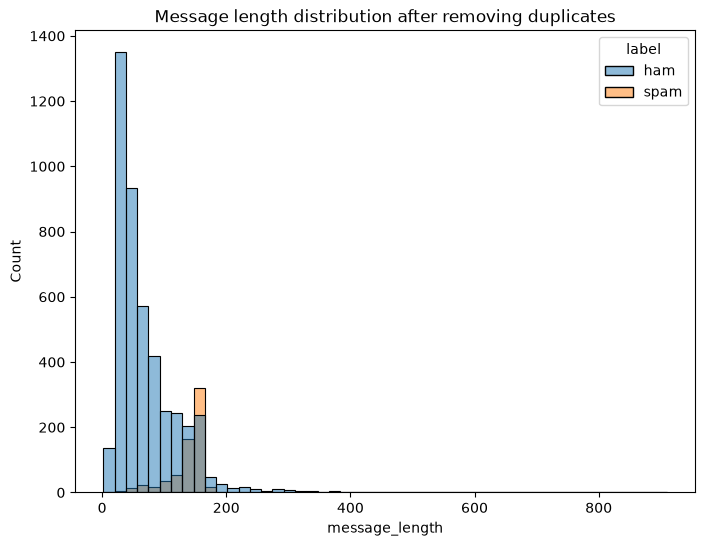

In [29]:
plt.figure(figsize=(8,6))
sns.histplot(
    data=df_copy,
    x='message_length',
    bins=50,
    hue='label'
)
plt.title("Message length distribution after removing duplicates")

In [30]:
df_copy['message'] = df_copy['message'].str.lower()

In [31]:
df_copy.head()

,label,message,label_num,message_lengh,message_length
0,ham,"go until jurong point, crazy.. available only ...",0,111,111
1,ham,ok lar... joking wif u oni...,0,29,29
2,spam,free entry in 2 a wkly comp to win fa cup fina...,1,155,155
3,ham,u dun say so early hor... u c already then say...,0,49,49
4,ham,"nah i don't think he goes to usf, he lives aro...",0,61,61


In [32]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [33]:
def remove_punctuation(text):
    return text.translate(str.maketrans("","",string.punctuation))

In [34]:
df_copy['message'] = df_copy['message'].apply(remove_punctuation)

In [35]:
df_copy.head()

,label,message,label_num,message_lengh,message_length
0,ham,go until jurong point crazy available only in ...,0,111,111
1,ham,ok lar joking wif u oni,0,29,29
2,spam,free entry in 2 a wkly comp to win fa cup fina...,1,155,155
3,ham,u dun say so early hor u c already then say,0,49,49
4,ham,nah i dont think he goes to usf he lives aroun...,0,61,61


# TOKENIZATION

In [37]:
df_copy.drop('message_lengh',axis=1,inplace=True)

In [38]:
df_copy.columns

Index(['label', 'message', 'label_num', 'message_length'], dtype='str')

In [39]:
df_copy['message'].apply(lambda x : x.split()).head()

0    [go, until, jurong, point, crazy, available, o...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, in, 2, a, wkly, comp, to, win, f...
3    [u, dun, say, so, early, hor, u, c, already, t...
4    [nah, i, dont, think, he, goes, to, usf, he, l...
Name: message, dtype: object

# Remove Stopwords

## ex: the is a an you and to have etc......

In [ ]:
#%pip install nltk

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.8 MB/s  0:00:00
   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   ------------------------------ --------- 524.3/676.6 kB 8.5 MB/s eta 0:00:01
   ------------------------------ --------- 524.3/676.6 kB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 676.6/676.6 kB 914.9 kB/s  0:00:00

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   --------------------------

In [41]:
import nltk
from nltk.corpus import stopwords

In [ ]:
#nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [43]:
stop_words = set(stopwords.words("english"))

In [44]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

In [45]:
df_copy['message'] = df_copy['message'].apply(remove_stopwords)

In [46]:
df_copy.head()

,label,message,label_num,message_length
0,ham,go jurong point crazy available bugis n great ...,0,111
1,ham,ok lar joking wif u oni,0,29
2,spam,free entry 2 wkly comp win fa cup final tkts 2...,1,155
3,ham,u dun say early hor u c already say,0,49
4,ham,nah dont think goes usf lives around though,0,61


# STEMMING

In [47]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [48]:
def stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

In [49]:
df_copy['message'] = df_copy['message'].apply(stemming)

In [50]:
df_copy.head()

,label,message,label_num,message_length
0,ham,go jurong point crazi avail bugi n great world...,0,111
1,ham,ok lar joke wif u oni,0,29
2,spam,free entri 2 wkli comp win fa cup final tkt 21...,1,155
3,ham,u dun say earli hor u c alreadi say,0,49
4,ham,nah dont think goe usf live around though,0,61


In [ ]:
df_copy['message'].head(10)

0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri 2 wkli comp win fa cup final tkt 21...
3                  u dun say earli hor u c alreadi say
4            nah dont think goe usf live around though
5    freemsg hey darl 3 week word back id like fun ...
6        even brother like speak treat like aid patent
7    per request mell mell oru minnaminungint nurun...
8    winner valu network custom select receivea £90...
9    mobil 11 month u r entitl updat latest colour ...
Name: message, dtype: str

In [52]:
df_copy['message'].str.contains(r'\d').sum()

np.int64(1328)

In [53]:
df_copy[df_copy['message'].str.contains(r'\d')].head()

,label,message,label_num,message_length
2,spam,free entri 2 wkli comp win fa cup final tkt 21...,1,155
5,spam,freemsg hey darl 3 week word back id like fun ...,1,147
7,ham,per request mell mell oru minnaminungint nurun...,0,160
8,spam,winner valu network custom select receivea £90...,1,157
9,spam,mobil 11 month u r entitl updat latest colour ...,1,154


In [54]:
from collections import Counter
all_words = ' '.join(df_copy['message']).split()
len(set(all_words))

8194

In [55]:
df_copy['message_length'].describe()

count    5169.000000
mean       79.344554
std        58.437457
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: message_length, dtype: float64

In [56]:
df_copy.to_csv('cleaned_SMSSpamCollection.csv',index=False)